In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmcrameri.cm as cm
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

from aidino.detector import Detector
from aidino.sample import Crystal
from aidino.diffraction import BraggCoherentDiffraction
from aidino.beam import GaussianBeam
from aidino.plot_utils import format_axis

In [2]:
dtype = torch.float32
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(dtype)

In [3]:
wavelength = 1.55e-10

detector = Detector(
    num_pixels_i = 512,
    num_pixels_j = 512,
    pixel_size = 50e-6,
    distance = 0.15,
    wavelength = wavelength,
    dtype = dtype,
    device = device
)
resolution = detector.calculate_resolution()
print(f'Detector resolution (ΔX): {resolution:.2g} m')

Detector resolution (ΔX): 9.1e-10 m


In [7]:
crystal_size = (1,1,1)

crystal = Crystal(
    '../cifs/MoS2_200Ax200A.cif',
    crystal_size = crystal_size,
    wavelength = wavelength,
    include_anomalous = True,
    dtype = dtype,
    device = device
)

lengths = crystal.lattice_vectors.norm(dim=1)

/home/oxygen16/NANDREJEVIC/Documents/AI-DINO/src/aidino/sample.py:133: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  self.structure = parser.parse_structures(primitive=False)[0]


In [8]:
crystal.visualize_structure()

Visualizing crystal of size (1, 1, 1) (13614 atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

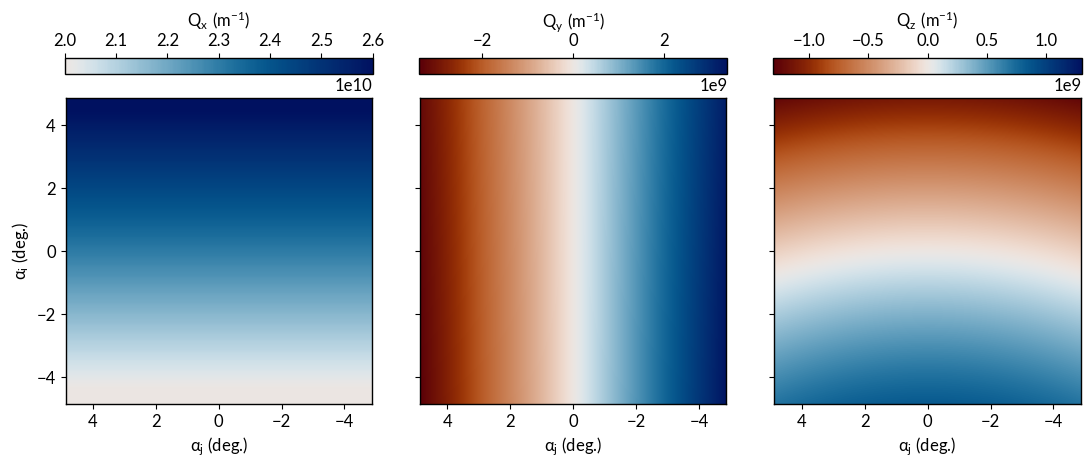

In [9]:
crystal.align_miller_plane_to_axis((0,1,0), target_axis='x')

theta_B = torch.deg2rad(torch.tensor(33.0 / 2., dtype=dtype, device=device))
k_i = torch.tensor([torch.sin(-theta_B), 0.0, torch.cos(-theta_B)], dtype=dtype, device=device)
k_f = torch.tensor([torch.sin(theta_B), 0.0, torch.cos(theta_B)], dtype=dtype, device=device)

q_vectors = detector.calculate_q_vectors(k_i, k_f)
fig = detector.plot_q_vectors(q_vectors)

In [10]:
crystal.visualize_structure()

Visualizing crystal of size (1, 1, 1) (13614 atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
supercell_size = (1,1,1)
q_batch_size = 32

In [12]:
simulator = BraggCoherentDiffraction(
    crystal = crystal
)

Execution time 2.90647029876709 s


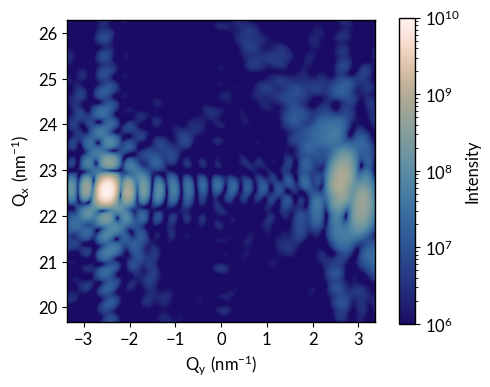

In [13]:
# Calculate intensity
t_start = time.time()
amplitude = simulator.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size)
intensity = (amplitude.abs() ** 2)
print('Execution time', time.time() - t_start, 's')
fig = detector.plot_intensity(intensity[-1], q_vectors)